# Feedforward Neural Networks (FNN) Demonstration In Python

## Objective
To develop a model/method for identifying customers who are likely to exit

## Background:
Bank customer churn, also known as customer attrition, refers to the phenomenon where customers stop doing business with a bank or switch to another bank. Churn is a critical metric for banks as it directly impacts their customer base and revenue. The dataset represents bank customer information for churn analysis. Each row in the dataset corresponds to a specific customer and contains several features or attributes that describe them.

While we have worked with Binary Logistic Regression, Naive Bayes, SVM and tree based methods in earlier case study, we will be using neural network in this one.

## Import Libraries


In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from skorch import NeuralNetClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [14]:
# Set seeds for reproducibility (mirrors random_state=42 / random_state=1)
torch.manual_seed(1)
np.random.seed(42)

### Import Data


In [15]:
data = pd.read_csv('Bank Churn.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Data Description


| Field           | Description                                            |
| --------------- | ------------------------------------------------------ |
| CustomerId      | Customer identifiers                                   |
| Surname         | Surname of Customer                                    |
| CreditScore     | Creditworthiness score of customers                    |
| Geography       | Country name                                           |
| Gender          | Gender of customer                                     |
| Age             | Age of customer                                        |
| Tenure          | Duration of customer engagement or membership          |
| Balance         | Amount of funds held in customer accounts              |
| NumOfProducts   | Number of products or services owned by customers      |
| HasCrCard       | Whether customers possess a credit card or not         |
| IsActiveMember  | Whether customers are active member of loyalty program |
| EstimatedSalary | The approximate salary of customers                    |
| Exited          | Whether customers have churned or exited the service   |


### Splitting Data into Train and Test data sets


In [16]:
X = data.drop(['RowNumber','CustomerId','Exited','Surname'],axis = 1)
y = data['Exited']


# Split data into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Create Dummies and Standardize numeric variables for Train and Test

In [17]:
#Standardize numeric variables

numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()

# Fit ONLY on training data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Use same scaler on test data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

#Define categorical columns
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

# Apply get_dummies on TRAIN
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

#Align test columns with train (VERY IMPORTANT)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


# Convert everything to numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


### Convert to PyTorch tensors
At this point X_train / X_test are pandas DataFrames and y_train / y_test are pandas Series — convenient for preprocessing but incompatible with PyTorch. All nn.Module layers, loss functions, and the autograd engine require torch.Tensor inputs. 

The conversion below is a one-time handoff: pandas handles cleaning/scaling/encoding, then PyTorch takes over for the entire forward pass, loss computation, and backpropagation

In [18]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

### Wrap in DataLoader for mini-batch training
`TensorDataset` pairs inputs with labels, `DataLoader` slices them into shuffled mini-batches of 32 for the training loop.

### Class Balance Check

In [19]:
counts = data['Exited'].value_counts().reset_index()
counts.columns = ['Exited', 'Freq']
counts['Percent'] = counts['Freq'] / counts['Freq'].sum()
print(counts)

   Exited  Freq  Percent
0       0  7963   0.7963
1       1  2037   0.2037


## Define & Train the Neural Network

#### NOTE :
No fixed rule → hyperparameter

32 is a balanced starting point

Not too small → avoids underfitting

Not too large → avoids overfitting

Thumb Rules:

- Between input size and output size

- Start with powers of 2 → 8, 16, 32, 64

- Use trial & error / validation performance

**Number of neurons is chosen experimentally based on performance.**

In [20]:
input_dim = X_train_t.shape[1]   # number of input features

###  1. Model with 4 Neurons (Simple Model)

A simple neural network with a single hidden layer of 4 neurons. This model has limited learning capacity and may underfit complex patterns in the data.

In [21]:
model_4 = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 4),   # Input → Hidden Layer (only 4 neurons)
                                   # Very small capacity → may underfit
        
        nn.ReLU(),                # Activation function (introduces non-linearity)
        
        nn.Linear(4, 1)           # Hidden lAYER ( 4 neurons) → Output (1 neuron for binary classification)
                                   # Outputs logit (raw score)
    ),

    max_epochs=300,              # Train for 300 iterations over full dataset

    optimizer=optim.Adam,        # Adam optimizer (adaptive learning)

    criterion=nn.BCEWithLogitsLoss,
    # Combines Sigmoid + Binary Cross Entropy
    # No need to add nn.Sigmoid() separately

    batch_size=32,               # Number of samples per batch

    verbose=0                    # No training logs
)
model_4.fit(X_train_t, y_train_t)


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=11, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=1, bias=True)
  ),
)

### 2. Model with 32 Neurons (Higher Capacity)

A neural network with a single hidden layer of 32 neurons. Increased neurons improve the model’s ability to capture complex relationships, leading to better performance.

In [22]:
model_32 = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 32),   # Input → Hidden Layer (32 neurons)
                                    # Higher capacity → learns complex patterns
        
        nn.ReLU(),                 # Activation
        
        nn.Linear(32, 1)           # Hidden → Output
                                    # Produces logit (raw prediction)
    ),

    max_epochs=300,               # Number of epochs

    optimizer=optim.Adam,         # Efficient gradient-based optimizer

    criterion=nn.BCEWithLogitsLoss,
    # Stable loss for binary classification

    batch_size=32,                # Mini-batch size

    verbose=0                     # Silent training
)

model_32.fit(X_train_t, y_train_t)


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  ),
)

### 3. Model with 2 Hidden Layers (Deeper Network)
A deeper neural network with two hidden layers. This architecture enables learning of more complex patterns but may increase the risk of overfitting if not regularized properly.

In [23]:
model_2hl = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 32),   # Input → Hidden Layer 1 (32 neurons)
                                    # Learns initial feature interactions
        
        nn.ReLU(),                 # Activation
        
        nn.Linear(32, 16),         # Hidden Layer 1 → Hidden Layer 2 (16 neurons)
                                    # Further refines learned features
        
        nn.ReLU(),                 # Activation
        
        nn.Linear(16, 1)           # Hidden Layer 2 → Output
                                    # Final prediction (logit)
    ),

    max_epochs=300,               # Training iterations

    optimizer=optim.Adam,         # Adaptive optimizer

    criterion=nn.BCEWithLogitsLoss,
    # Handles sigmoid internally

    batch_size=32,                # Batch size

    verbose=0                     # No logs
)

model_2hl.fit(X_train_t, y_train_t)

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  ),
)

In [24]:
def evaluate_model(model, X_test_t, y_test_t):
    
    # Get logits
    y_logits = model.predict_proba(X_test_t)[:, 1]
    
    # Convert to class (0/1)
    y_pred = (y_logits > 0.5).astype(int)
    
    print("Classification Report:\n")
    print(classification_report(y_test_t, y_pred))
    
    auc = roc_auc_score(y_test_t, y_logits)
    print("AUC Score:", auc)
    
    return auc

In [25]:
print("Model with 4 neurons")
evaluate_model(model_4, X_test_t, y_test_t)

print("\nModel with 32 neurons")
evaluate_model(model_32, X_test_t, y_test_t)

print("\nModel with 2 hidden layers")
evaluate_model(model_2hl, X_test_t, y_test_t)

Model with 4 neurons
Classification Report:

              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91      1593
         1.0       0.72      0.34      0.46       407

    accuracy                           0.84      2000
   macro avg       0.79      0.65      0.68      2000
weighted avg       0.83      0.84      0.81      2000

AUC Score: 0.7991319516743246

Model with 32 neurons
Classification Report:

              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91      1593
         1.0       0.66      0.55      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000

AUC Score: 0.8414439092405193

Model with 2 hidden layers
Classification Report:

              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90      1593
         1.0       0.62      0.46

0.7846143524109626

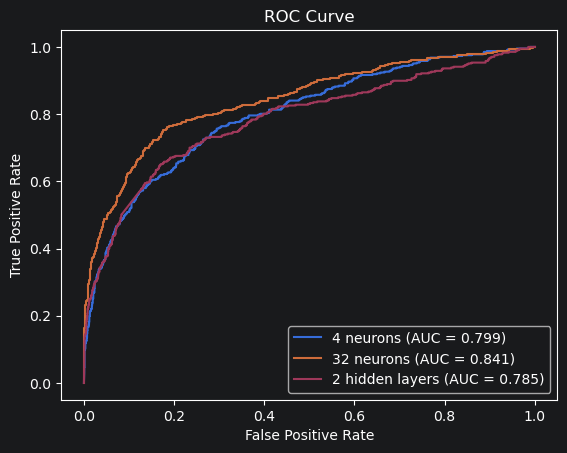

In [26]:
def plot_roc(model, X_test_t, y_test_t, title):
    # Get predicted probabilities
    y_probs = model.predict_proba(X_test_t)[:, 1]
    
    # ROC values
    fpr, tpr, _ = roc_curve(y_test_t, y_probs)
    
    # AUC calculation
    auc_score = roc_auc_score(y_test_t, y_probs)
    
    # Plot with AUC in legend
    plt.plot(fpr, tpr, label=f"{title} (AUC = {auc_score:.3f})")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

# Plot multiple models
plot_roc(model_4, X_test_t, y_test_t, "4 neurons")
plot_roc(model_32, X_test_t, y_test_t, "32 neurons")
plot_roc(model_2hl, X_test_t, y_test_t, "2 hidden layers")

plt.show()

### Conclusion :

The model with 32 neurons performs the best, achieving the highest AUC (~0.84), indicating better classification ability